In [83]:
import polars as pl #Used to read parquet files
from fractions import Fraction #Used to get a more accurate gear ratio
import numpy as np #Used for pi, sqrt, and to make arrays of the data
import matplotlib.pyplot as plt #Used to plot every graph: Speed v. Time, Car Accelerating, Car Braking, Car Coasting, and Car GPS Path

In [84]:
#Reads the parquet file and forward fills all of the null values
data_frame = pl.read_parquet("C:\\Users\\DCAGa\\Downloads\\software-data.parquet").fill_null(strategy = "forward")

In [85]:
#Prints the data frame. Optional parameter to only print select columns
def print_data_frame(data_frame, columns = None):

    #Checks if a second parameter was inputed
    if columns is not None:
        
        #If so, it selects the desired columns
        data_frame = data_frame.select(columns)

    print(data_frame)

In [86]:
print_data_frame(data_frame) #WITHOUT 'columns' parameter
print_data_frame(data_frame, ["ETC_STATUS_PEDAL_TRAVEL", "SME_TEMP_ControllerTemperature", "SME_TRQSPD_Speed"]) #WITH 'columns' parameter

shape: (13_838, 255)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Time      ┆ SME_THROT ┆ SME_THROT ┆ SME_THROT ┆ … ┆ SMPC_INPU ┆ SMPC_SER_ ┆ SMPC_SER_ ┆ SMPC_SER │
│ ---       ┆ L_TorqueD ┆ L_MaxSpee ┆ L_Forward ┆   ┆ T_MAX_CHA ┆ PART_NUMB ┆ SERIAL_NU ┆ _FIRMWAR │
│ f64       ┆ emand     ┆ d         ┆ ---       ┆   ┆ RGER_TEMP ┆ ER        ┆ MBER      ┆ E_VER    │
│           ┆ ---       ┆ ---       ┆ f64       ┆   ┆ _C        ┆ ---       ┆ ---       ┆ ---      │
│           ┆ f64       ┆ f64       ┆           ┆   ┆ ---       ┆ f64       ┆ f64       ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0.0       ┆ 0.0       ┆ 7500.0    ┆ 1.0       ┆ … ┆ -50.0     ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ 0.011917  ┆ 0.0       ┆ 7500.0    ┆ 1.0       ┆ … ┆ -50.0     ┆ 0.0 

In [87]:
#Grabs all the values from a column and converts them into a NumPy array
def get_values(column_name):
    
    return data_frame[column_name].to_numpy()

In [ ]:
GEAR_RATIO = Fraction(12, 41)
WHEEL_RADIUS = 0.2 #meters

motor_RPM = get_values("SME_TRQSPD_Speed") #RPM
time = get_values("Time") #seconds

#Converts all of the motor_RPM values to velocities (m/s)
velocity = motor_RPM * GEAR_RATIO * (np.pi / 30) * WHEEL_RADIUS #v = mRPM * GR * (pi / 30) * WR

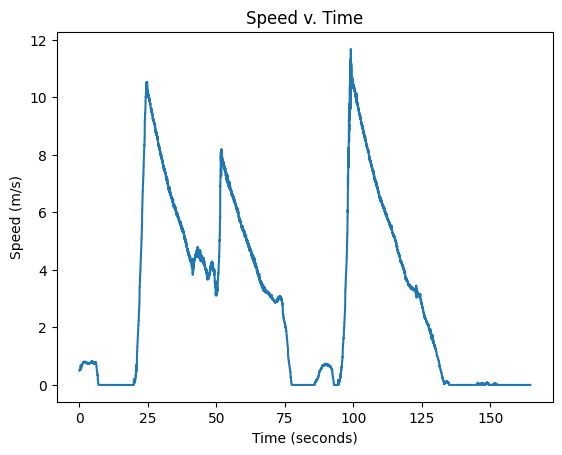

In [89]:
#Displays a Speed v. Time graph
plt.plot(time, velocity)
plt.title("Speed v. Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Speed (m/s)")
plt.show()

In [90]:
#Finds the cars speed at a certain time. If the time isn't recorded in the data it finds the next closet value
def speed_at_time(target_time):

    #min(..., key = ...) is used the find the lowest indice. abs(time[i] - target_time) is used to find which index is smallest
    index = min(
        range(len(time)),
        #Checks how far a time is from the target time
        key = lambda i: abs(time[i] - target_time)
    )
    
    #Prints the time the speed was recorded and the speed itself
    print("Time:", time[index], "\nSpeed:", velocity[index], "m/s")

In [91]:
print(speed_at_time(10))

Time: 9.998013902681231 
Speed: 0.0 m/s
None


In [92]:
ACCELERATION_THRESHOLD = 0.1 #Gives a margin of error of 0.1 for when the car's coasting

acceleration = get_values("VDM_Y_AXIS_ACCELERATION")
states = []

#Creates NumPy arrays for the three states (accelerating, braking, & coasting)
accelerating = np.where(
    acceleration > ACCELERATION_THRESHOLD,
    acceleration,
    np.nan
)

braking = np.where(
    acceleration < -ACCELERATION_THRESHOLD,
    acceleration,
    np.nan
)

coasting = np.where(
    (acceleration >= -ACCELERATION_THRESHOLD) & (acceleration <= ACCELERATION_THRESHOLD),
    acceleration,
    np.nan
)

for i in acceleration:

    if i > ACCELERATION_THRESHOLD:
        states.append("Accelerating")

    elif i < -ACCELERATION_THRESHOLD:
        states.append("Braking")

    else:
        states.append("Coasting")

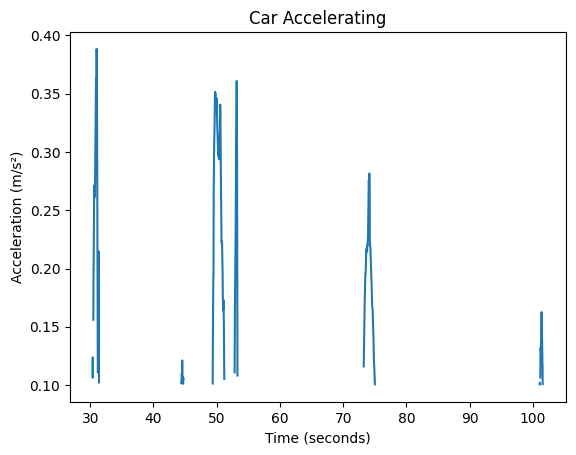

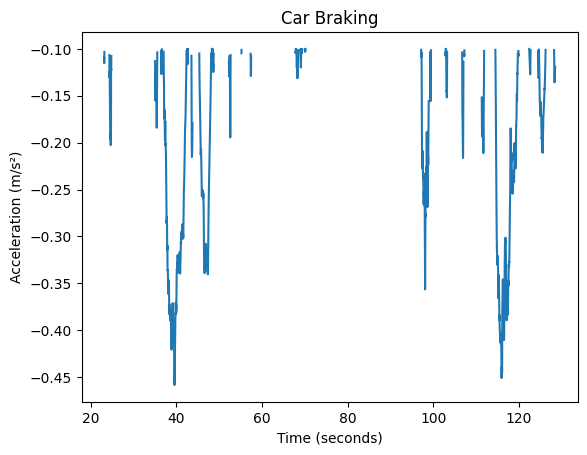

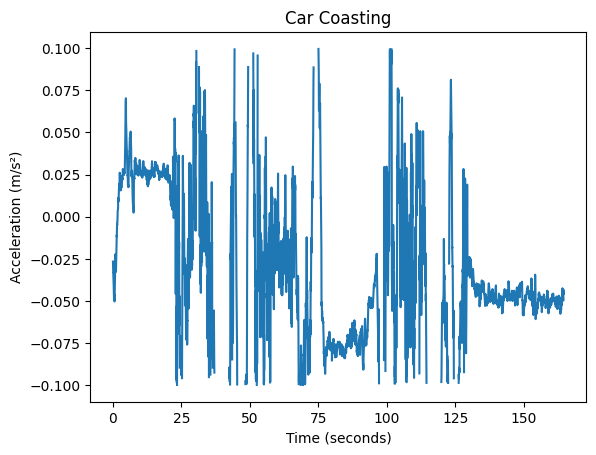

In [93]:
#Displays a graph that shows when the car is accelerating
plt.plot(time, accelerating)
plt.title("Car Accelerating")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (m/s²)")
plt.show()

#Displays a graph that shows when the car braking
plt.plot(time, braking)
plt.title("Car Braking")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (m/s²)")
plt.show()

#Displays a graph that shows when the car is coasting
plt.plot(time, coasting)
plt.title("Car Coasting")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (m/s²)")
plt.show()

In [94]:
#Finds and prints the time ranges for each state
start = 0

for i in range(1, len(states)):

    #A change in state means the previous time range has ended
    if states[i] != states[i - 1]:

        print(states[start], "from", time[start], "to", time[i - 1])
        #Start recording the new state
        start = i
        
#Prints the final states after reaching the end of the data
print(states[start], "from", time[start], "to", time[-1])

Coasting from 0.0 to 23.16583912611718
Braking from 23.177755710029793 to 23.213505461767628
Coasting from 23.22542204568024 to 23.249255213505464
Braking from 23.261171797418076 to 23.261171797418076
Coasting from 23.273088381330687 to 23.36842105263158
Braking from 23.38033763654419 to 23.38033763654419
Coasting from 23.392254220456802 to 24.369414101290964
Braking from 24.381330685203576 to 24.846077457795435
Coasting from 24.857994041708046 to 30.363413359599765
Accelerating from 30.37528749377748 to 30.43465816466606
Coasting from 30.446532298843778 to 30.482154701376928
Accelerating from 30.49402883555464 to 31.396463033061075
Coasting from 31.40833716723879 to 35.029948091442236
Braking from 35.04182222561995 to 35.564284129439464
Coasting from 35.57615826361718 to 36.41922179023503
Braking from 36.431095924412745 to 36.66857860796707
Coasting from 36.68045274214479 to 37.024802633298556
Braking from 37.03667676747627 to 42.391911281626285
Coasting from 42.403785415804 to 42.534

In [103]:
latitude = get_values("VDM_GPS_Latitude")
longitude = get_values("VDM_GPS_Longitude")
print_data_frame(data_frame, ["VDM_GPS_Latitude", "VDM_GPS_Longitude"])

shape: (13_838, 2)
┌──────────────────┬───────────────────┐
│ VDM_GPS_Latitude ┆ VDM_GPS_Longitude │
│ ---              ┆ ---               │
│ f64              ┆ f64               │
╞══════════════════╪═══════════════════╡
│ 38.575493        ┆ -121.733124       │
│ 38.575493        ┆ -121.733124       │
│ 38.575493        ┆ -121.733124       │
│ 38.575493        ┆ -121.733124       │
│ 38.575493        ┆ -121.733124       │
│ …                ┆ …                 │
│ 38.575489        ┆ -121.732132       │
│ 38.575489        ┆ -121.732132       │
│ 38.575489        ┆ -121.732132       │
│ 38.575489        ┆ -121.732132       │
│ 38.575489        ┆ -121.732132       │
└──────────────────┴───────────────────┘


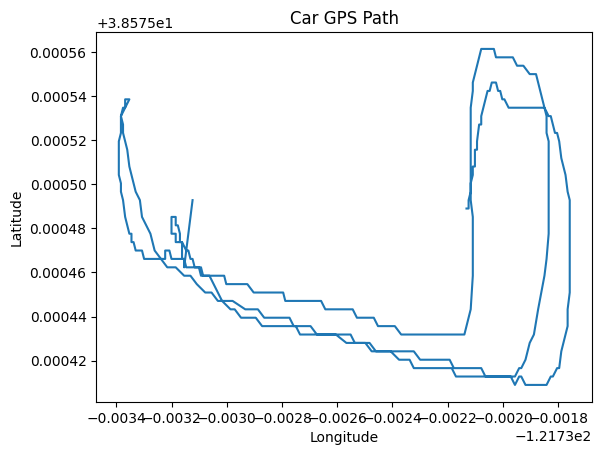

In [96]:
#Displays the position (longitude and latitudes) of the car to visualize the track
plt.plot(longitude, latitude)
plt.title("Car GPS Path")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [97]:
#Uses the car's first GPS position as the start/finish line
start_latitude = latitude[0]
start_longitude = longitude[0]

#Calculates how far every GPS point is from the starting position
distance = np.sqrt(
    (latitude - start_latitude) ** 2
    + (longitude - start_longitude) ** 2
)

#Sets how close the car needs to be to the starting point for it to be considered to be crossing the start/finish line
START_LINE_DISTANCE = 0.0001

crossings = []

for i in range(len(distance)):

    #If the car is close enough to the starting position, save the index of that GPS point
    if distance[i] < START_LINE_DISTANCE:

        crossings.append(i)

#The car usually has several consecutive GPS points that are within the START_LINE_DISTANCE when it approaches the start/finish line. Group those consecutive points together so they count as one crossing instead of a bunch of crossings.
crossing_groups, group = [], []

for i in crossings:

    #If this is the first point in a group, or if this point comes immediately after the previous point, add it to the group
    if len(group) == 0 or i == group[-1] + 1:

        group.append(i)

    else:

        #If point is no longer consecutive, add group to crossing_groups and then add the non-consecutive point to the now-empty group
        crossing_groups.append(group)
        group = [i]

#Add the final group after the loop finishes
if len(group) > 0:

    crossing_groups.append(group)

#Finds one representative time for each crossing. We use the middle GPS point of each group
lap_times = []

for group in crossing_groups:

    #Finds the middle point of the group
    middle = group[len(group) // 2]

    #Saves the time at which the car crossed the start/finish line
    lap_times.append(time[middle])

#There's one more crossing than completed laps. For example, 4 crossings create 3 complete laps.
print("Number of laps:", len(lap_times) - 1)

#Prints the starting, ending, and total times for every lap.
for i in range(len(lap_times) - 1):

    print("Lap", i + 1, "from", lap_times[i], "to", lap_times[i + 1], " Total lap time:", lap_times[i + 1] - lap_times[i])

Number of laps: 2
Lap 1 from 12.679245283018869 to 66.27079511301358  Total lap time: 53.591549829994705
Lap 2 from 66.27079511301358 to 100.4288741451127  Total lap time: 34.158079032099124
